In [16]:
import numpy as np
import pandas as pn

In [17]:
df=pn.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [18]:
df_new = df.copy()
df_new

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [21]:
a=round(df_new['Age'].mean())
a

30

In [24]:
df_new['Age'].fillna(a,inplace=True)
df_new.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x1e1a59c3bb0>,
 'caps': [<matplotlib.lines.Line2D at 0x1e1a59cf310>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e1a59c3820>],
 'medians': [<matplotlib.lines.Line2D at 0x1e1a59cfa30>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e1a59cfdc0>],
 'means': []}

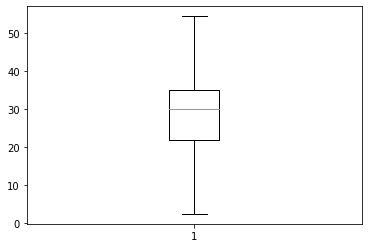

In [25]:
#CAPPING UPPER AUR LOWER VALUE
import matplotlib.pyplot as plt
import numpy as np
outliers = []
def detect_bounds_iqr(data):
    q1 = np.percentile(data,25)
    q3 = np.percentile(data,75)
    #print(q1,q3)
    IQR = q3 - q1
    lower_bound = q1 - (1.5*IQR)
    upper_bound = q3 + (1.5*IQR)
    #print(lower-bound,upper_bound)
    return upper_bound,lower_bound

upper_bound,lower_bound = detect_bounds_iqr(df_new['Age'])
df_new['Age'] = np.where(df_new['Age'] > upper_bound, upper_bound, df_new['Age'])
df_new['Age'] = np.where(df_new['Age'] < lower_bound, lower_bound, df_new['Age'])
plt.boxplot(df_new['Age'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1e1a5a8bee0>,
 'caps': [<matplotlib.lines.Line2D at 0x1e1a5a99640>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e1a5a8bb20>],
 'medians': [<matplotlib.lines.Line2D at 0x1e1a5a99d60>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e1a5aa5130>],
 'means': []}

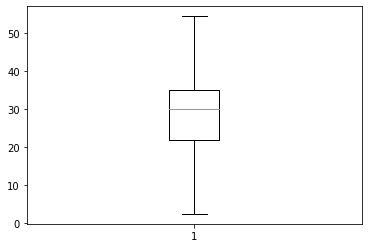

In [28]:
#CAPPING UPPER AUR LOWER VALUE OR MEAN
import matplotlib.pyplot as plt
import numpy as np
outliers = []
def detect_bounds_iqr(data):
    q1 = np.percentile(data,25)
    q3 = np.percentile(data,75)
    #print(q1,q3)
    IQR = q3 - q1
    lower_bound = q1 - (1.5*IQR)
    upper_bound = q3 + (1.5*IQR)
    #print(lower-bound,upper_bound)
    return upper_bound,lower_bound

upper_bound,lower_bound = detect_bounds_iqr(df_new['Age'])
mean_val = round(df_new['Age'].mean())
df_new['Age'] = np.where(df_new['Age'] > upper_bound, mean_val, df_new['Age'])
df_new['Age'] = np.where(df_new['Age'] < lower_bound, mean_val, df_new['Age'])
plt.boxplot(df_new['Age'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1e1a5afc820>,
 'caps': [<matplotlib.lines.Line2D at 0x1e1a5afcf40>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e1a5afc490>],
 'medians': [<matplotlib.lines.Line2D at 0x1e1a5b056a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e1a5b05a30>],
 'means': []}

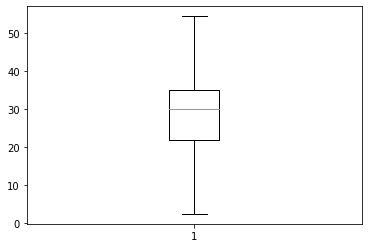

In [29]:
#CAPPING UPPER AUR LOWER VALUE OR MEAN
import matplotlib.pyplot as plt
import numpy as np
outliers = []
def detect_bounds_iqr(data):
    q1 = np.percentile(data,25)
    q3 = np.percentile(data,75)
    #print(q1,q3)
    IQR = q3 - q1
    lower_bound = q1 - (1.5*IQR)
    upper_bound = q3 + (1.5*IQR)
    #print(lower-bound,upper_bound)
    return upper_bound,lower_bound

upper_bound,lower_bound = detect_bounds_iqr(df_new['Age'])
df_new['Age'] = np.where(df_new['Age'] > upper_bound, a, df_new['Age'])
df_new['Age'] = np.where(df_new['Age'] < lower_bound, a, df_new['Age'])
plt.boxplot(df_new['Age'])